Ejecutando simulación base para análisis de Estado Estable...


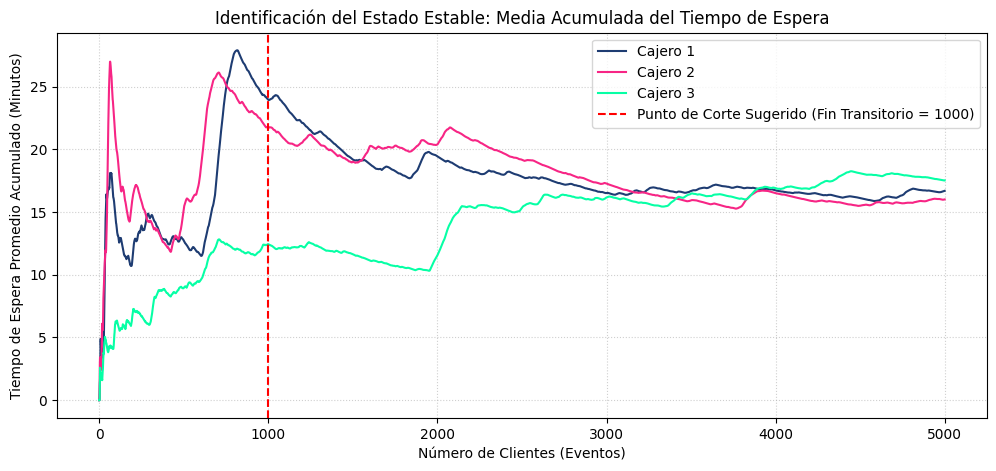

--------Cajero con menor y mayor tiempo promedio de atención---------
⏱ Tiempo promedio de atención Cajero 1: 3.63 minutos
⏱ Tiempo promedio de atención Cajero 2: 3.61 minutos
⏱ Tiempo promedio de atención Cajero 3: 3.65 minutos
--------Promedio de usuarios de cada tipo en la totalidad de los cajeros---------
Distribución Real de Usuarios en la Simulación:
  • Rápido: 3653 usuarios (24.35%)
  • Normal: 3016 usuarios (20.11%)
  • Lento: 4116 usuarios (27.44%)
  • Muy Lento: 4215 usuarios (28.10%)
--------Eliminación del Estado Transitorio (Antes y Después)---------


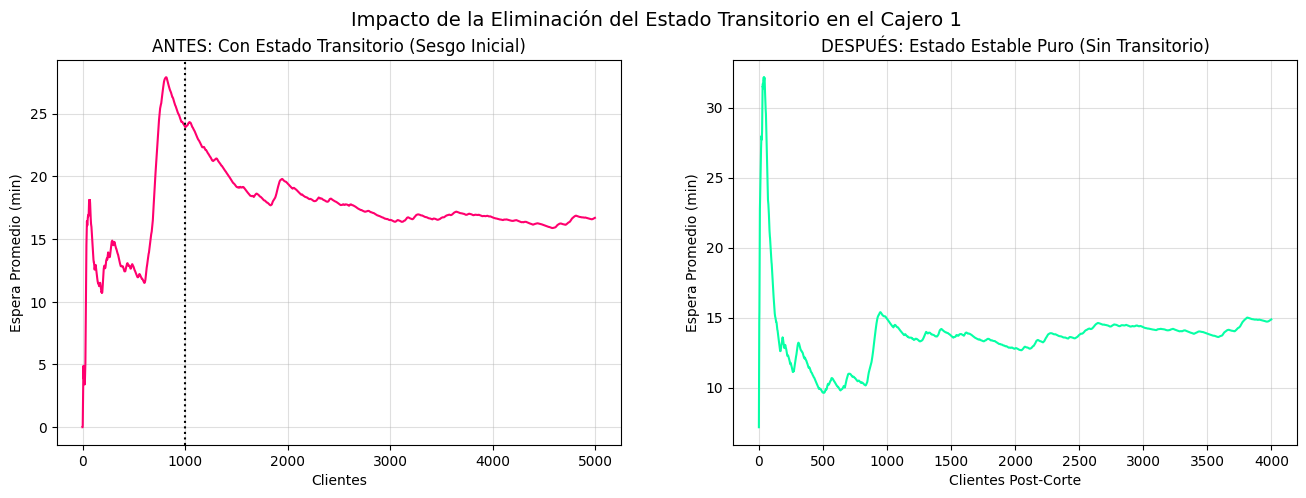

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DE PARÁMETROS Y PROBABILIDADES
PROBS = [0.25, 0.20, 0.275, 0.275]  # Rápido, Normal, Lento, Muy Lento
MEDIAS_LLEGADA = [3.0, 3.0, 5.0, 7.0]
MEDIAS_SERVICIO = [1.0, 3.0, 4.0, 6.0]
NOMBRES_TIPOS = ['Rápido', 'Normal', 'Lento', 'Muy Lento']

def generar_cliente():
    """Genera un cliente basado en las probabilidades de su perfil."""
    r = random.random()
    acumulada = 0
    for i, p in enumerate(PROBS):
        acumulada += p
        if r <= acumulada:
            t_llegada = random.expovariate(1.0 / MEDIAS_LLEGADA[i])
            t_servicio = random.expovariate(1.0 / MEDIAS_SERVICIO[i])
            return i, t_llegada, t_servicio

def simular_cajero(num_clientes):
    """Simula un cajero M/M/1 registrando las métricas por evento."""
    tiempo_actual = 0.0
    tiempo_libre_servidor = 0.0

    # Listas de registro histórico
    tiempos_atencion = []
    conteo_tipos = [0, 0, 0, 0]
    historial_tiempo_espera = []

    for _ in range(num_clientes):
        tipo, t_llegada, t_servicio = generar_cliente()
        conteo_tipos[tipo] += 1

        # El tiempo avanza con la llegada del cliente
        tiempo_actual += t_llegada

        # Si el cajero está libre, se atiende de inmediato, si no, espera
        if tiempo_actual < tiempo_libre_servidor:
            espera = tiempo_libre_servidor - tiempo_actual
            tiempo_libre_servidor += t_servicio
        else:
            espera = 0.0
            tiempo_libre_servidor = tiempo_actual + t_servicio

        tiempos_atencion.append(t_servicio)
        historial_tiempo_espera.append(espera)

    return tiempos_atencion, conteo_tipos, historial_tiempo_espera

# 2. DETERMINACIÓN DEL ESTADO ESTABLE (MÉTODO DE LA MEDIA ACUMULADA)
print("Ejecutando simulación base para análisis de Estado Estable...")
random.seed(42)  # Fijar semilla para replicabilidad
NUM_CLIENTES_BASE = 5000

t_atencion_c1, tipos_c1, esperas_c1 = simular_cajero(NUM_CLIENTES_BASE)
t_atencion_c2, tipos_c2, esperas_c2 = simular_cajero(NUM_CLIENTES_BASE)
t_atencion_c3, tipos_c3, esperas_c3 = simular_cajero(NUM_CLIENTES_BASE)

# Calcular medias acumuladas del tiempo de espera para observar convergencia
medias_acum_c1 = np.cumsum(esperas_c1) / (np.arange(NUM_CLIENTES_BASE) + 1)
medias_acum_c2 = np.cumsum(esperas_c2) / (np.arange(NUM_CLIENTES_BASE) + 1)
medias_acum_c3 = np.cumsum(esperas_c3) / (np.arange(NUM_CLIENTES_BASE) + 1)

# Graficar Medias Acumuladas
plt.figure(figsize=(12, 5))
plt.plot(medias_acum_c1, label='Cajero 1', color='#1e3c72')
plt.plot(medias_acum_c2, label='Cajero 2', color='#f72585')
plt.plot(medias_acum_c3, label='Cajero 3', color='#06ffa5')
plt.axvline(x=1000, color='red', linestyle='--', label='Punto de Corte Sugerido (Fin Transitorio = 1000)')
plt.title('Identificación del Estado Estable: Media Acumulada del Tiempo de Espera')
plt.xlabel('Número de Clientes (Eventos)')
plt.ylabel('Tiempo de Espera Promedio Acumulado (Minutos)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#------------------------------------------
#Cajero con menor y mayor tiempo promedio de atención
#------------------------------------------
print("--------Cajero con menor y mayor tiempo promedio de atención---------")
print(f"⏱ Tiempo promedio de atención Cajero 1: {np.mean(t_atencion_c1):.2f} minutos")
print(f"⏱ Tiempo promedio de atención Cajero 2: {np.mean(t_atencion_c2):.2f} minutos")
print(f"⏱ Tiempo promedio de atención Cajero 3: {np.mean(t_atencion_c3):.2f} minutos")

#------------------------------------------
#Promedio de usuarios de cada tipo en la totalidad de los cajeros
#------------------------------------------
print("--------Promedio de usuarios de cada tipo en la totalidad de los cajeros---------")
totales_por_tipo = np.array(tipos_c1) + np.array(tipos_c2) + np.array(tipos_c3)
gran_total = np.sum(totales_por_tipo)

print("Distribución Real de Usuarios en la Simulación:")
for i, nombre in enumerate(NOMBRES_TIPOS):
    print(f"  • {nombre}: {totales_por_tipo[i]} usuarios ({totales_por_tipo[i]/gran_total*100:.2f}%)")

#------------------------------------------
#Eliminación del Estado Transitorio (Antes y Después)
#------------------------------------------
print("--------Eliminación del Estado Transitorio (Antes y Después)---------")
# Recorte del estado transitorio (Warm-up period de 1000 clientes)
corte = 1000

esperas_estables_c1 = esperas_c1[corte:]
medias_post_c1 = np.cumsum(esperas_estables_c1) / (np.arange(len(esperas_estables_c1)) + 1)

# Graficar el Antes y el Después
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica del ANTES
ax1.plot(medias_acum_c1, color='#ff006e')
ax1.axvline(x=corte, color='black', linestyle=':')
ax1.set_title('ANTES: Con Estado Transitorio (Sesgo Inicial)')
ax1.set_xlabel('Clientes')
ax1.set_ylabel('Espera Promedio (min)')
ax1.grid(True, alpha=0.4)

# Gráfica del DESPUÉS
ax2.plot(medias_post_c1, color='#06ffa5')
ax2.set_title('DESPUÉS: Estado Estable Puro (Sin Transitorio)')
ax2.set_xlabel('Clientes Post-Corte')
ax2.set_ylabel('Espera Promedio (min)')
ax2.grid(True, alpha=0.4)

plt.suptitle('Impacto de la Eliminación del Estado Transitorio en el Cajero 1', fontsize=14)
plt.show()